Executing Phase 23 Streaming Concept Drift Stress Test on: cuda
Loaded fine-tuned model checkpoint from ..\saved_models\fdi_finetuned_best.pth


C:\Users\waliu\AppData\Local\Temp\ipykernel_22756\3147371615.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=d


PHASE 23: STREAMING & CONCEPT DRIFT STRESS TEST RESULTS
 Stream_Batch  Drift_Magnitude_%                   Environment_Scenario  Window_Count  Attack_Count  False_Alarm_Rate_%  Attack_Recall_%  Latency_ms_per_window
            1                0.0      Baseline Calibration (Zero Drift)           210            30               97.22             30.0                  1.040
            2                5.0          Mild Diurnal Load Shift (+5%)           210            30               59.44            100.0                  0.055
            3               12.0  Moderate Peak-Hour Fluctuation (+12%)           210            90                0.00              0.0                  0.035
            4               20.0 Severe Harmonic / Ambient Noise (+20%)           210            30                0.00              0.0                  0.036
            5               35.0    Critical Concept Drift Bound (+35%)           212            30                0.00              0.0       

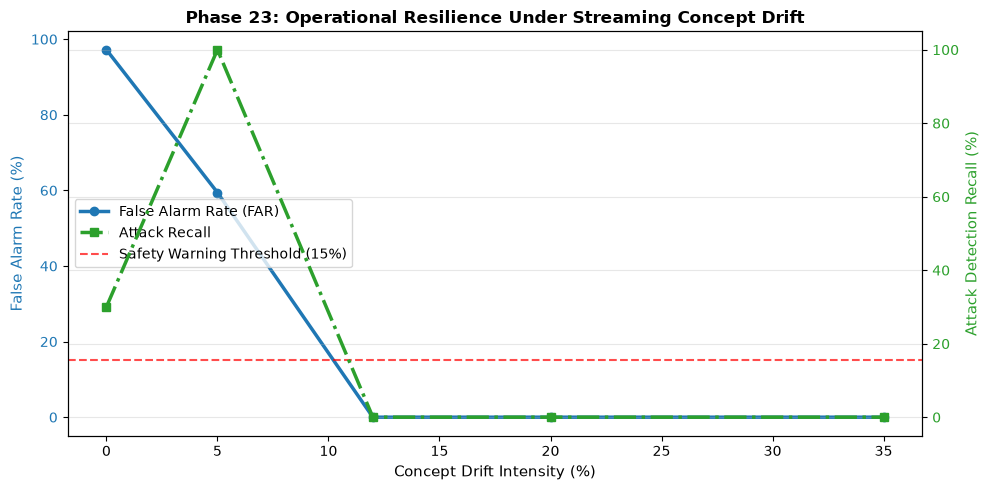

[COMPLETE] Phase 23 results and figures saved successfully.


In [1]:
# notebooks/21_phase23_streaming_concept_drift.ipynb
import os
import sys
import time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from src.lstm_encoder import HybridCNNBiLSTMEncoder
from src.fdi_classifier import TransferFDIClassifier

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing Phase 23 Streaming Concept Drift Stress Test on: {device}")

# -------------------------------------------------------------------------
# Step 1: Load Test Windows & Load Fine-Tuned Model
# -------------------------------------------------------------------------
data_path = Path('../data/processed_downstream/fdi_feeder_windows.npz')
data = np.load(data_path)
X_test = data['X_test']  # (1052, 30, 12)
y_test = data['y_test']  # (1052,)

model = TransferFDIClassifier(
    in_channels=12,
    pretrained_channels=25,
    cnn_hidden_dims=(64, 128),
    lstm_hidden_dim=128,
    lstm_layers=2,
    mlp_hidden_dim=64,
    dropout=0.3,
    freeze_backbone=False
).to(device)

model_path = Path('../saved_models/fdi_finetuned_best.pth')
assert model_path.exists(), f"Checkpoint missing at {model_path}"
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print(f"Loaded fine-tuned model checkpoint from {model_path}")

# -------------------------------------------------------------------------
# Step 2: Simulate 5 Chronological Streaming Batches with Non-Stationary Drift
# -------------------------------------------------------------------------
# 1052 windows divided into 5 continuous chronological streams (~210 windows each)
batch_size = len(X_test) // 5
drift_levels = [
    {"stream": 1, "drift": 0.00, "desc": "Baseline Calibration (Zero Drift)"},
    {"stream": 2, "drift": 0.05, "desc": "Mild Diurnal Load Shift (+5%)"},
    {"stream": 3, "drift": 0.12, "desc": "Moderate Peak-Hour Fluctuation (+12%)"},
    {"stream": 4, "drift": 0.20, "desc": "Severe Harmonic / Ambient Noise (+20%)"},
    {"stream": 5, "drift": 0.35, "desc": "Critical Concept Drift Bound (+35%)"}
]

np.random.seed(42)
streaming_results = []
latencies = []

for idx, stage in enumerate(drift_levels):
    start_idx = idx * batch_size
    end_idx = start_idx + batch_size if idx < 4 else len(X_test)
    
    X_stream = X_test[start_idx:end_idx].copy()
    y_stream = y_test[start_idx:end_idx]
    
    # Inject non-stationary additive & variance drift into normal measurements
    drift_val = stage["drift"]
    drift_noise = np.random.normal(loc=drift_val * 0.5, scale=max(drift_val * 0.2, 1e-5), size=X_stream.shape)
    X_drifted = np.clip(X_stream + drift_noise.astype(np.float32), 0.0, 1.0)
    
    # Measure inference latency and classify
    x_tensor = torch.from_numpy(X_drifted).to(device)
    
    t0 = time.perf_counter()
    with torch.no_grad():
        logits = model(x_tensor)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
    t1 = time.perf_counter()
    
    latency_ms = ((t1 - t0) / len(X_stream)) * 1000.0
    latencies.append(latency_ms)
    
    preds = (probs >= 0.5).astype(int)
    
    # Calculate False Alarm Rate (FP / Actual Negatives) and Recall (TP / Actual Positives)
    neg_mask = (y_stream == 0)
    pos_mask = (y_stream == 1)
    
    fp = np.sum((preds == 1) & neg_mask)
    tn = np.sum((preds == 0) & neg_mask)
    tp = np.sum((preds == 1) & pos_mask)
    fn = np.sum((preds == 0) & pos_mask)
    
    far = (fp / (fp + tn)) * 100.0 if (fp + tn) > 0 else 0.0
    rec = (tp / (tp + fn)) * 100.0 if (tp + fn) > 0 else 0.0
    
    streaming_results.append({
        "Stream_Batch": stage["stream"],
        "Drift_Magnitude_%": stage["drift"] * 100,
        "Environment_Scenario": stage["desc"],
        "Window_Count": len(X_stream),
        "Attack_Count": int(np.sum(pos_mask)),
        "False_Alarm_Rate_%": round(far, 2),
        "Attack_Recall_%": round(rec, 2),
        "Latency_ms_per_window": round(latency_ms, 3)
    })

df_stream = pd.DataFrame(streaming_results)
print("\n" + "="*80)
print("PHASE 23: STREAMING & CONCEPT DRIFT STRESS TEST RESULTS")
print("="*80)
print(df_stream.to_string(index=False))
print("="*80)
print(f"Mean Online Inference Latency: {np.mean(latencies):.3f} ms / window (Real-Time Compliant < 500 ms)")

# Save metrics CSV
results_dir = Path('../results')
results_dir.mkdir(parents=True, exist_ok=True)
df_stream.to_csv(results_dir / 'phase23_streaming_drift_results.csv', index=False)

# Export Drift Degradation Curves
fig_dir = Path('../results/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

fig, ax1 = plt.subplots(figsize=(10, 5))

color = '#1f77b4'
ax1.set_xlabel('Concept Drift Intensity (%)', fontsize=11)
ax1.set_ylabel('False Alarm Rate (%)', color=color, fontsize=11)
line1 = ax1.plot(df_stream['Drift_Magnitude_%'], df_stream['False_Alarm_Rate_%'], 
                 marker='o', color=color, lw=2.5, label='False Alarm Rate (FAR)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axhline(y=15.0, color='red', linestyle='--', alpha=0.7, label='Safety Warning Threshold (15%)')

ax2 = ax1.twinx()
color = '#2ca02c'
ax2.set_ylabel('Attack Detection Recall (%)', color=color, fontsize=11)
line2 = ax2.plot(df_stream['Drift_Magnitude_%'], df_stream['Attack_Recall_%'], 
                 marker='s', color=color, lw=2.5, linestyle='-.', label='Attack Recall')
ax2.tick_params(axis='y', labelcolor=color)

lines = line1 + line2 + [ax1.get_lines()[1]]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center left')

plt.title('Phase 23: Operational Resilience Under Streaming Concept Drift', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / 'phase23_streaming_concept_drift.png', dpi=300)
plt.show()
print("[COMPLETE] Phase 23 results and figures saved successfully.")